# Notebook 02 — pLDDT Structural Confidence Analysis

**Goal:** Extract and compare AlphaFold confidence scores across the FHL protein family.

**Key finding:** FHL1 has a disordered C-terminal tail (residues 230–325) absent in FHL2/3/4.

In [1]:
#GOAL: extract pLDDT confidence scores for FHL1 and compute summary statistics
#WHY? pLDDT is AlphaFold's per-residue confidence score (0-100)
#stored in the B-factor column of ATOM lines in the PDB file
#high pLDDT = structured, low pLDDT = disordered

import numpy as np

with open("../data/raw/FHL1.pdb", "r") as file:
    lines = file.readlines()

plddt_scores = []
for line in lines:
    if line.startswith("ATOM"):
        #pLDDT is stored in columns 60-66 (B-factor field)
        plddt = float(line[60:66].strip())
        plddt_scores.append(plddt)

print(f"FHL1 average pLDDT:          {np.mean(plddt_scores):.1f}")
print(f"% highly confident (>90):    {sum(s > 90 for s in plddt_scores)/len(plddt_scores)*100:.1f}%")
print(f"% disordered (<50):          {sum(s < 50 for s in plddt_scores)/len(plddt_scores)*100:.1f}%")

FHL1 average pLDDT:          73.1
% highly confident (>90):    40.4%
% disordered (<50):          26.4%


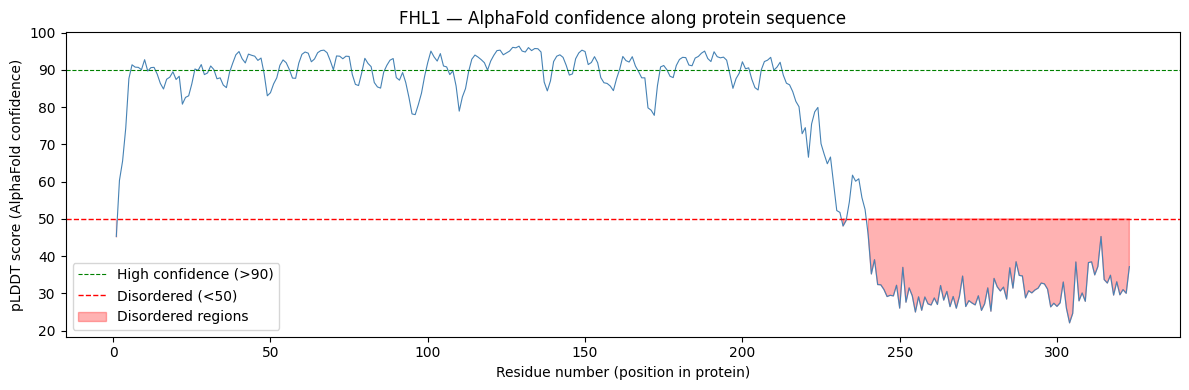

In [2]:
#GOAL: plot pLDDT score residue by residue along FHL1's sequence
#WHY? The average hides where disorder occurs — we need the per-residue profile
#to identify the disordered tail vs the structured LIM domains
#CA atom = alpha-carbon, one per residue — gives exactly one score per amino acid

import matplotlib.pyplot as plt

residue_scores = {}
with open("../data/raw/FHL1.pdb", "r") as file:
    for line in file:
        if line.startswith("ATOM"):
            parts = line.split()
            if parts[2] == "CA":
                residue_num = int(parts[5])
                plddt = float(parts[10])
                residue_scores[residue_num] = plddt

residues = sorted(residue_scores.keys())
scores = [residue_scores[r] for r in residues]

plt.figure(figsize=(12, 4))
plt.plot(residues, scores, linewidth=0.8, color="steelblue")
plt.axhline(y=90, color="green", linestyle="--", linewidth=0.8, label="High confidence (>90)")
plt.axhline(y=50, color="red", linestyle="--", linewidth=1, label="Disordered (<50)")
plt.fill_between(residues, scores, 50,
                 where=[s < 50 for s in scores],
                 color="red", alpha=0.3, label="Disordered regions")
plt.xlabel("Residue number (position in protein)")
plt.ylabel("pLDDT score (AlphaFold confidence)")
plt.title("FHL1 — AlphaFold confidence along protein sequence")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/FHL1_plddt_plot.png", dpi=300)
plt.show()

#FINDING: confidence drops sharply at residue ~230 and stays below 50 to the end
#this is the disordered C-terminal tail unique to FHL1

In [3]:
#GOAL: compare pLDDT statistics across all 4 FHL family members
#WHY? To show FHL1 is structurally unusual — the others are fully structured
#NOTE: FHL4 (Q8CDC8) is Mus musculus (mouse) — human FHL4 not in AlphaFold

import numpy as np

filename_map = {
    "FHL1": "FHL1",
    "FHL2": "Q14192",
    "FHL3": "Q13643",
    "FHL4": "Q8CDC8",  #mouse (Mus musculus) — noted as limitation
}
results = {}

for gene, filename in filename_map.items():
    with open(f"../data/raw/{filename}.pdb", "r") as file:
        lines = file.readlines()

    plddt_scores = []
    for line in lines:
        if line.startswith("ATOM"):
            plddt = float(line[60:66].strip())
            plddt_scores.append(plddt)

    results[gene] = {
        "avg": np.mean(plddt_scores),
        "high_conf": sum(s > 90 for s in plddt_scores) / len(plddt_scores) * 100,
        "disordered": sum(s < 50 for s in plddt_scores) / len(plddt_scores) * 100,
    }

print(f"{'Gene':<8} {'Avg pLDDT':>12} {'>90% conf':>12} {'<50% disord':>12}")
print("-" * 46)
for gene, r in results.items():
    print(f"{gene:<8} {r['avg']:>12.1f} {r['high_conf']:>11.1f}% {r['disordered']:>11.1f}%")

Gene        Avg pLDDT    >90% conf  <50% disord
----------------------------------------------
FHL1             73.1        40.4%        26.4%
FHL2             92.3        81.5%         0.0%
FHL3             91.8        79.3%         0.4%
FHL4             92.2        81.3%         0.0%


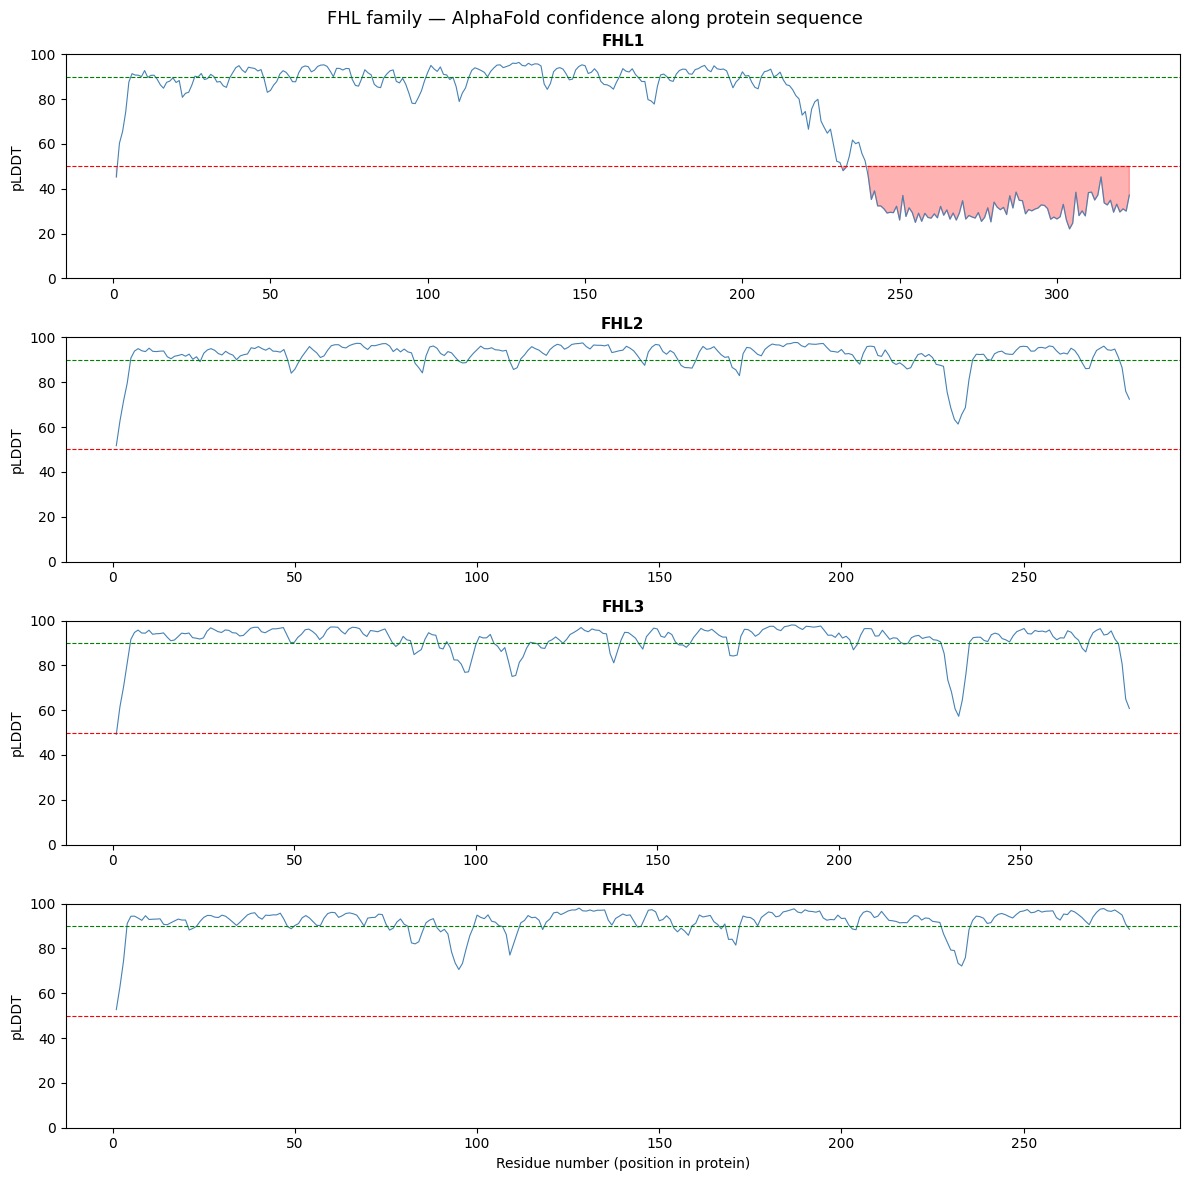

In [4]:
#GOAL: plot pLDDT for all 4 FHL proteins in a 4-panel figure
#WHY? Visual comparison makes it immediately obvious FHL1 is the outlier
#sharex=False because proteins have different lengths

import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=False)

for ax, (gene, filename) in zip(axes, filename_map.items()):
    residue_scores = {}
    with open(f"../data/raw/{filename}.pdb", "r") as file:
        for line in file:
            if line.startswith("ATOM"):
                parts = line.split()
                if parts[2] == "CA":
                    residue_num = int(parts[5])
                    plddt = float(parts[10])
                    residue_scores[residue_num] = plddt

    residues = sorted(residue_scores.keys())
    scores = [residue_scores[r] for r in residues]

    ax.plot(residues, scores, linewidth=0.8, color="steelblue")
    ax.axhline(y=90, color="green", linestyle="--", linewidth=0.8)
    ax.axhline(y=50, color="red", linestyle="--", linewidth=0.8)
    ax.fill_between(residues, scores, 50,
                    where=[s < 50 for s in scores],
                    color="red", alpha=0.3)
    ax.set_title(gene, fontsize=11, fontweight="bold")
    ax.set_ylabel("pLDDT")
    ax.set_ylim(0, 100)

axes[-1].set_xlabel("Residue number (position in protein)")
fig.suptitle("FHL family — AlphaFold confidence along protein sequence", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/FHL_comparison_plddt.png", dpi=300)
plt.show()

#FINDING: FHL2/3/4 stay above 90 throughout
#FHL1 is the only family member with a disordered tail (red region, residues 230-325)